# PatchCore — Results Analysis
Notebook for visualizing results produced by `evaluate()` and `evaluate_from_db()`.

**Supported inputs:**
- CSV from `evaluate()` — columns: `name, mu, sigma, threshold, free_scores, fp_count, obstr_score, is_tp`
- CSV from `evaluate_from_db()` — columns: `reference_id, test_id, test_type, venue_type, file_path, score, threshold, is_anomaly`
- SQLite DB (optional) — tables `experiments` + `results`

Set the paths in the configuration cell, then run everything with **Run All**.

In [15]:
# ── Dependencies ────────────────────────────────────────────────────────────────
# pip install pandas matplotlib seaborn scikit-learn opencv-python pillow

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_curve, roc_auc_score, precision_recall_curve

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [16]:
# ── Configuration ────────────────────────────────────────────────────────────

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
SOURCE = 'evaluate_db'  # or 'evaluate' for simple CSV
CSV_PATH = 'results_p3_shadow04.csv'
DB_PATH = None  # e.g., 'occlusion.db'

def resolve_input_path(raw_path: str) -> Path:
    """Resolve a file path by checking multiple roots."""
    candidate = Path(raw_path)
    if candidate.is_absolute():
        return candidate
    search_roots = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]
    for root in search_roots:
        resolved = (root / candidate).resolve()
        if resolved.exists():
            return resolved
    return (NOTEBOOK_DIR.parent / candidate).resolve()

CSV_FILE = resolve_input_path(CSV_PATH)
print(f'CSV file resolved to: {CSV_FILE}')
print(f'File exists: {CSV_FILE.exists()}')

CSV file resolved to: C:\Users\andrea\OneDrive - University of Pisa\Università\Unipi\tesi\src\results_p3_shadow04.csv
File exists: True


---
## 1. Data Loading

In [17]:
# ── Load CSV and normalize to common format ──────────────────────────────────

def load_evaluate_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate() — one row per background image."""
    df = pd.read_csv(path)
    # free_scores is stored as JSON string '[0.123, ...]'
    df['free_scores'] = df['free_scores'].apply(json.loads)
    # Expand into separate rows (one for each free test)
    free_rows = []
    for _, row in df.iterrows():
        for s in row['free_scores']:
            free_rows.append({
                'name': row['name'],
                'score': s,
                'threshold': row['threshold'],
                'test_type': 'normal',
                'is_anomaly': int(s > row['threshold']),
                'venue_type': 'n/a',
            })
        if pd.notna(row.get('obstr_score')):
            free_rows.append({
                'name': row['name'],
                'score': row['obstr_score'],
                'threshold': row['threshold'],
                'test_type': 'obstructed',
                'is_anomaly': int(row['is_tp']) if pd.notna(row.get('is_tp')) else None,
                'venue_type': 'n/a',
            })
    return pd.DataFrame(free_rows)


def load_evaluate_db_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate_from_db() — one row per (reference, test) pair."""
    df = pd.read_csv(path)
    df['is_anomaly'] = df['is_anomaly'].astype(int)
    return df


if SOURCE == 'evaluate':
    df = load_evaluate_csv(str(CSV_FILE))
else:
    df = load_evaluate_db_csv(str(CSV_FILE))

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows loaded: 2970
Columns: ['reference_id', 'test_id', 'test_type', 'venue_type', 'file_path', 'score', 'normalized_score', 'threshold', 'is_anomaly']


,reference_id,test_id,test_type,venue_type,file_path,score,normalized_score,threshold,is_anomaly
0,non_ostruite/corridoi/corridoio_001.jpeg,non_ostruite/corridoi/corridoio_001.jpeg,normal,corridoio,non_ostruite/corridoi/corridoio_001.jpeg,2.660499,-1.007553,3.638147,0
1,non_ostruite/corridoi/corridoio_001.jpeg,shadow_test/normali_corridoi/corridoio_001_sha...,shadow_normal,corridoio,shadow_test/normali_corridoi/corridoio_001_sha...,3.264092,1.466682,3.638147,0
2,non_ostruite/corridoi/corridoio_001.jpeg,ostruzioni_reali/images/corridoio_001_ostruita...,obstructed,corridoio,ostruzioni_reali/images/corridoio_001_ostruita...,4.971309,8.464866,3.638147,1
3,non_ostruite/corridoi/corridoio_002.jpg,non_ostruite/corridoi/corridoio_002.jpg,normal,corridoio,non_ostruite/corridoi/corridoio_002.jpg,2.444528,-0.601225,3.923119,0
4,non_ostruite/corridoi/corridoio_002.jpg,shadow_test/normali_corridoi/corridoio_002_sha...,shadow_normal,corridoio,shadow_test/normali_corridoi/corridoio_002_sha...,3.037405,0.842776,3.923119,0


In [18]:
# ── Split data by test_type ─────────────────────────────────────────────────

normal_df = df[df['test_type'] == 'normal']
obstructed_df = df[df['test_type'] == 'obstructed']
shadow_df = df[df['test_type'] == 'shadow_normal']

print(f'Normal:     {len(normal_df)} rows')
print(f'Obstructed: {len(obstructed_df)} rows')
print(f'Shadow:     {len(shadow_df)} rows')
print(f'Total:      {len(df)} rows')
print(f'test_type values in CSV: {sorted(df["test_type"].unique())}')

Normal:     990 rows
Obstructed: 990 rows
Shadow:     990 rows
Total:      2970 rows
test_type values in CSV: ['normal', 'obstructed', 'shadow_normal']


---
## 2. Anomaly Score Distribution

C:\Users\andrea\AppData\Local\Temp\ipykernel_3300\1519520903.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=labels)


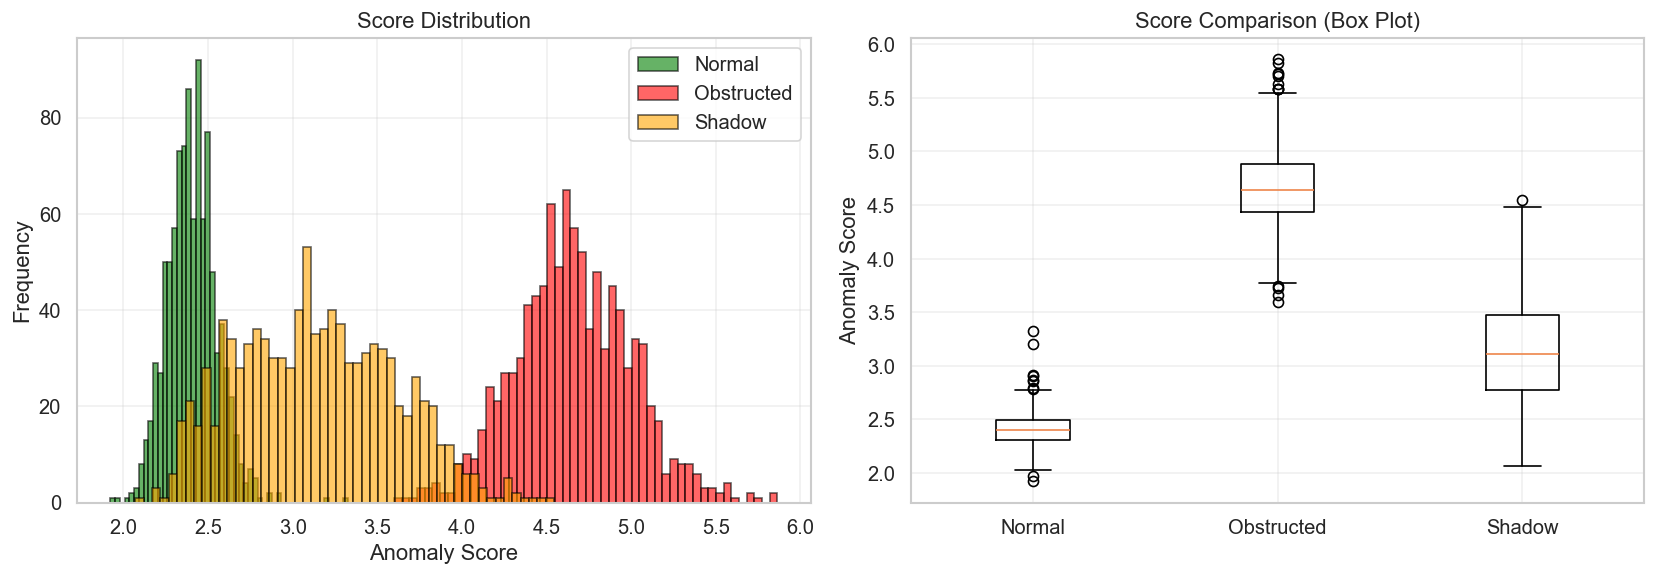

=== Score Statistics ===
Normal:     mean=2.4081, std=0.1474
Obstructed: mean=4.6583, std=0.3434
Shadow:     mean=3.1350, std=0.4595


In [19]:
# ── Score distribution ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(normal_df['score'], bins=50, alpha=0.6, label='Normal', color='green', edgecolor='black')
axes[0].hist(obstructed_df['score'], bins=50, alpha=0.6, label='Obstructed', color='red', edgecolor='black')
if len(shadow_df) > 0:
    axes[0].hist(shadow_df['score'], bins=50, alpha=0.6, label='Shadow', color='orange', edgecolor='black')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [normal_df['score'], obstructed_df['score']]
labels = ['Normal', 'Obstructed']
if len(shadow_df) > 0:
    data_to_plot.append(shadow_df['score'])
    labels.append('Shadow')
axes[1].boxplot(data_to_plot, labels=labels)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Score Comparison (Box Plot)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print('=== Score Statistics ===')
print(f'Normal:     mean={normal_df["score"].mean():.4f}, std={normal_df["score"].std():.4f}')
print(f'Obstructed: mean={obstructed_df["score"].mean():.4f}, std={obstructed_df["score"].std():.4f}')
if len(shadow_df) > 0:
    print(f'Shadow:     mean={shadow_df["score"].mean():.4f}, std={shadow_df["score"].std():.4f}')

---
## 3. ROC Curve and Precision-Recall

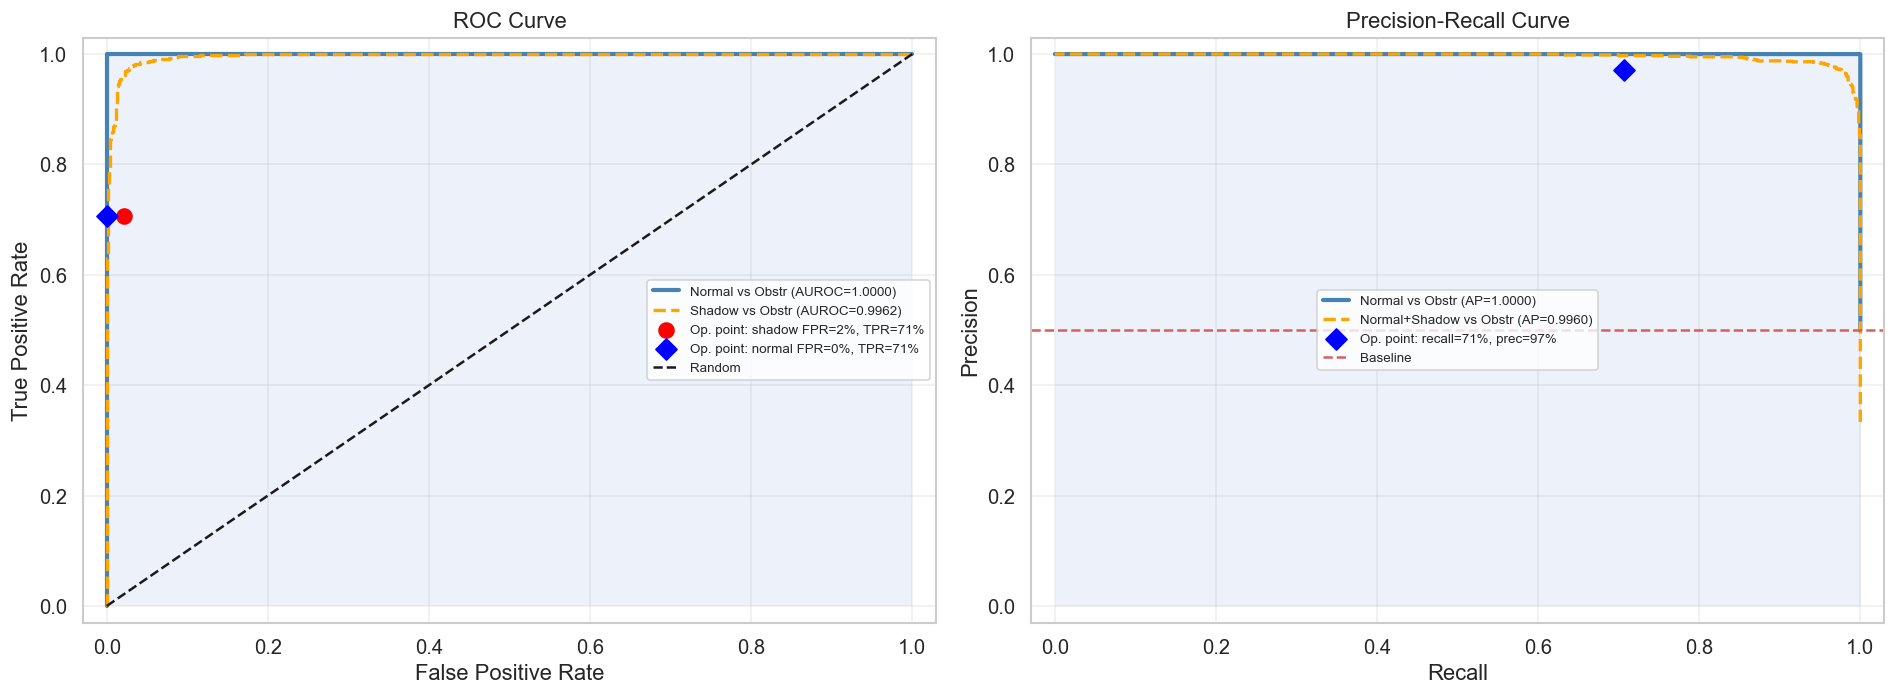

AUROC (Normal vs Obstr):         1.0000
AP    (Normal vs Obstr):         1.0000
AUROC (Shadow vs Obstr):         0.9962
AP    (Normal+Shadow vs Obstr):  0.9960

Operating point (per-reference adaptive thresholds):
  Normal FPR:  0.00%
  Shadow FPR:  2.12%
  Obstr TPR:   70.61%
  Obstr FNR:   29.39%


In [20]:
# ── ROC Curve and Precision-Recall ──────────────────────────────────────────

has_shadow = len(shadow_df) > 0

# Baseline: Normal (0) vs Obstructed (1)
scores_no = pd.concat([normal_df['score'], obstructed_df['score']], ignore_index=True)
labels_no = pd.concat([
    pd.Series([0] * len(normal_df)),
    pd.Series([1] * len(obstructed_df))
], ignore_index=True)
fpr_c, tpr_c, thr_roc = roc_curve(labels_no, scores_no)
auroc = roc_auc_score(labels_no, scores_no)
prec_c, rec_c, thr_pr = precision_recall_curve(labels_no, scores_no)
ap = average_precision_score(labels_no, scores_no)

# Shadow robustness: Shadow (0) vs Obstructed (1) — for ROC
# Normal+Shadow (0) vs Obstructed (1) — for PR curve
if has_shadow:
    scores_sh = pd.concat([shadow_df['score'], obstructed_df['score']], ignore_index=True)
    labels_sh = pd.concat([
        pd.Series([0] * len(shadow_df)),
        pd.Series([1] * len(obstructed_df))
    ], ignore_index=True)
    fpr_sh, tpr_sh, thr_sh = roc_curve(labels_sh, scores_sh)
    auroc_sh = roc_auc_score(labels_sh, scores_sh)

    scores_nsh = pd.concat([normal_df['score'], shadow_df['score'], obstructed_df['score']], ignore_index=True)
    labels_nsh = pd.concat([
        pd.Series([0] * len(normal_df)),
        pd.Series([0] * len(shadow_df)),
        pd.Series([1] * len(obstructed_df))
    ], ignore_index=True)
    prec_nsh, rec_nsh, _ = precision_recall_curve(labels_nsh, scores_nsh)
    ap_nsh = average_precision_score(labels_nsh, scores_nsh)

# Operating point — read directly from is_anomaly (per-reference decision already in CSV)
op_normal_fpr = normal_df['is_anomaly'].mean()
op_obstr_tpr  = obstructed_df['is_anomaly'].mean()
tp_op = obstructed_df['is_anomaly'].sum()
fp_op = normal_df['is_anomaly'].sum()
if has_shadow:
    op_shadow_fpr = shadow_df['is_anomaly'].mean()
    fp_op += shadow_df['is_anomaly'].sum()
op_obstr_prec = tp_op / max(tp_op + fp_op, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: ROC ────────────────────────────────────────────────────────────────
axes[0].plot(fpr_c, tpr_c, lw=2.5, color='steelblue',
             label=f'Normal vs Obstr (AUROC={auroc:.4f})')
if has_shadow:
    axes[0].plot(fpr_sh, tpr_sh, lw=2, color='orange', linestyle='--',
                 label=f'Shadow vs Obstr (AUROC={auroc_sh:.4f})')
    axes[0].scatter([op_shadow_fpr], [op_obstr_tpr], color='red', zorder=5, s=80,
                    label=f'Op. point: shadow FPR={op_shadow_fpr:.0%}, TPR={op_obstr_tpr:.0%}')
axes[0].scatter([op_normal_fpr], [op_obstr_tpr], color='blue', zorder=5, s=80, marker='D',
                label=f'Op. point: normal FPR={op_normal_fpr:.0%}, TPR={op_obstr_tpr:.0%}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[0].fill_between(fpr_c, tpr_c, alpha=0.1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.03, 1.03])
axes[0].set_ylim([-0.03, 1.03])

# ── Right: Precision-Recall ───────────────────────────────────────────────────
axes[1].plot(rec_c, prec_c, lw=2.5, color='steelblue',
             label=f'Normal vs Obstr (AP={ap:.4f})')
if has_shadow:
    axes[1].plot(rec_nsh, prec_nsh, lw=2, color='orange', linestyle='--',
                 label=f'Normal+Shadow vs Obstr (AP={ap_nsh:.4f})')
axes[1].scatter([op_obstr_tpr], [op_obstr_prec], color='blue', zorder=5, s=80, marker='D',
                label=f'Op. point: recall={op_obstr_tpr:.0%}, prec={op_obstr_prec:.0%}')
axes[1].axhline(y=labels_no.sum() / len(labels_no), color='r', linestyle='--', lw=1.5, label='Baseline')
axes[1].fill_between(rec_c, prec_c, alpha=0.1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-0.03, 1.03])
axes[1].set_ylim([-0.03, 1.03])

plt.tight_layout()
plt.show()

print(f'AUROC (Normal vs Obstr):         {auroc:.4f}')
print(f'AP    (Normal vs Obstr):         {ap:.4f}')
if has_shadow:
    print(f'AUROC (Shadow vs Obstr):         {auroc_sh:.4f}')
    print(f'AP    (Normal+Shadow vs Obstr):  {ap_nsh:.4f}')
print()
print('Operating point (per-reference adaptive thresholds):')
print(f'  Normal FPR:  {op_normal_fpr:.2%}')
if has_shadow:
    print(f'  Shadow FPR:  {op_shadow_fpr:.2%}')
print(f'  Obstr TPR:   {op_obstr_tpr:.2%}')
print(f'  Obstr FNR:   {1-op_obstr_tpr:.2%}')

---
## 4. FPR / TPR per venue_type

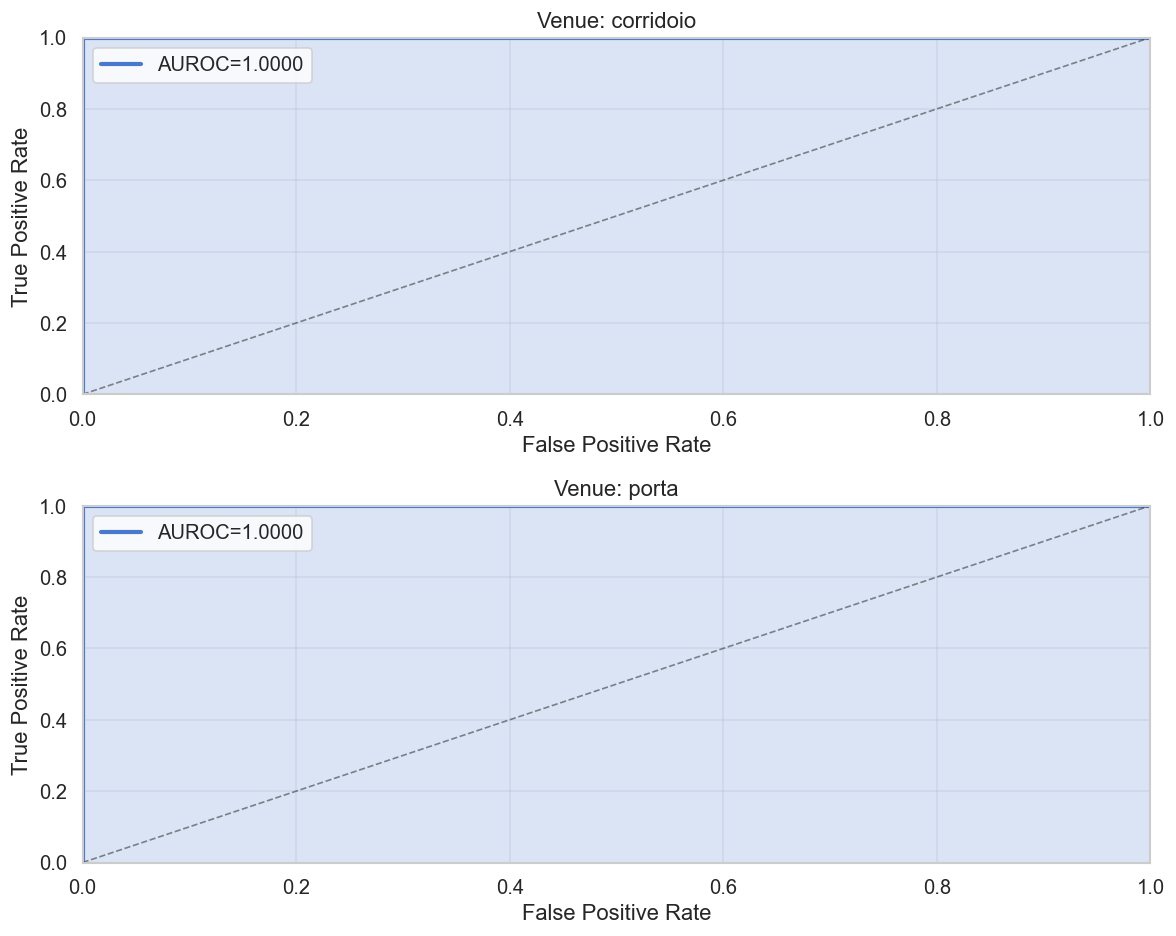

In [21]:
# ── Per-Venue Analysis (if venue_type available) ──────────────────────────────

if 'venue_type' in df.columns and df['venue_type'].nunique() > 1:
    venues = df['venue_type'].unique()
    fig, axes = plt.subplots(len(venues), 1, figsize=(10, 4*len(venues)))
    if len(venues) == 1:
        axes = [axes]
    
    for i, venue in enumerate(venues):
        venue_df = df[df['venue_type'] == venue]
        normal_venue = venue_df[venue_df['test_type'] == 'normal']
        obstructed_venue = venue_df[venue_df['test_type'] == 'obstructed']
        
        if len(obstructed_venue) > 0:
            labels_venue = pd.concat([
                pd.Series([0] * len(normal_venue)),
                pd.Series([1] * len(obstructed_venue))
            ], ignore_index=True)
            scores_venue = pd.concat([
                normal_venue['score'],
                obstructed_venue['score']
            ], ignore_index=True)
            
            auroc_venue = roc_auc_score(labels_venue, scores_venue)
            fpr_v, tpr_v, _ = roc_curve(labels_venue, scores_venue)
            
            axes[i].plot(fpr_v, tpr_v, lw=2.5, label=f'AUROC={auroc_venue:.4f}')
            axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
            axes[i].fill_between(fpr_v, tpr_v, alpha=0.2)
            axes[i].set_xlabel('False Positive Rate')
            axes[i].set_ylabel('True Positive Rate')
            axes[i].set_title(f'Venue: {venue}')
            axes[i].legend()
            axes[i].grid(alpha=0.3)
            axes[i].set_xlim([0, 1])
            axes[i].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

---
## 5. Shadow FPR - Robustness to Synthetic Shadows

Shadow robustness (n=990):
  Correctly not flagged (TN): 969
  Incorrectly flagged   (FP): 21
  Shadow FPR:                 0.0212 (2.1%)


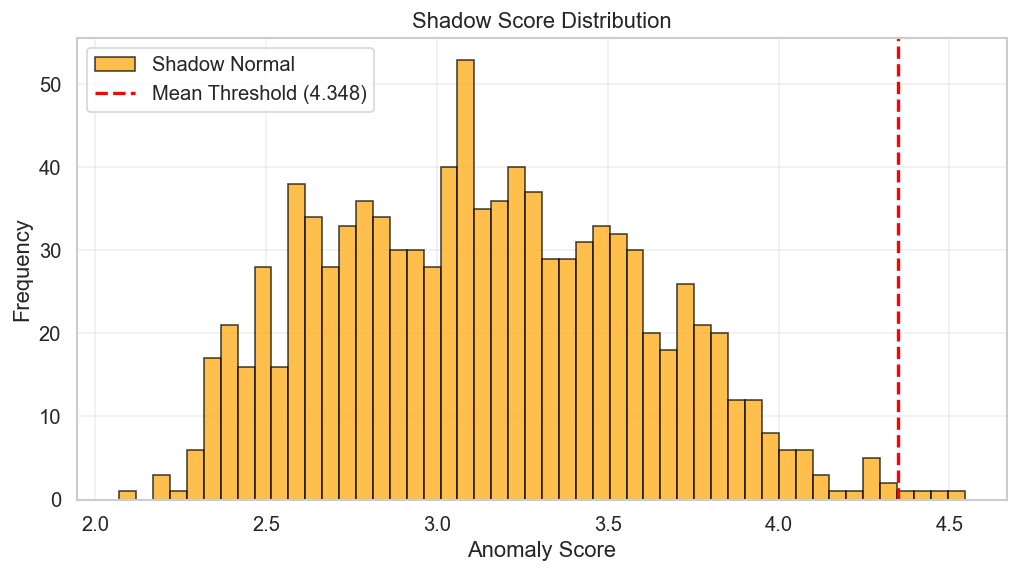

In [22]:
# ── Shadow FPR: Robustness to synthetic shadows ───────────────────────────────
# shadow_normal images are NORMAL frames (expected is_anomaly=0).

if len(shadow_df) > 0:
    shadow_fp_count = (shadow_df['is_anomaly'] == 1).sum()
    shadow_tn_count = (shadow_df['is_anomaly'] == 0).sum()
    shadow_fpr = shadow_fp_count / len(shadow_df)

    print(f'Shadow robustness (n={len(shadow_df)}):')
    print(f'  Correctly not flagged (TN): {shadow_tn_count}')
    print(f'  Incorrectly flagged   (FP): {shadow_fp_count}')
    print(f'  Shadow FPR:                 {shadow_fpr:.4f} ({shadow_fpr:.1%})')

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(shadow_df['score'], bins=50, alpha=0.7, color='orange', edgecolor='black', label='Shadow Normal')
    mean_thr = shadow_df['threshold'].mean()
    ax.axvline(mean_thr, color='red', linestyle='--', linewidth=2, label=f'Mean Threshold ({mean_thr:.3f})')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Shadow Score Distribution')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print('No shadow test data available.')

---
## 6. Score per image - ranking

FPR — clean normal only:          0/990 = 0.00%
FPR — shadow normal only:         21/990 = 2.12%
FPR — combined (clean + shadow):  21/1980 = 1.06%

Top 10 FPs (all normal images):
          test_type     score  threshold venue_type
1560  shadow_normal  4.484057   2.574263      porta
1884  shadow_normal  4.389917   4.347193      porta
1194  shadow_normal  4.071758   3.728452  corridoio
1789  shadow_normal  3.912502   3.401730      porta
1096  shadow_normal  3.889171   3.829629  corridoio
1320  shadow_normal  3.866104   3.416918  corridoio
1626  shadow_normal  3.767790   3.543046      porta
1680  shadow_normal  3.724613   3.465965      porta
1907  shadow_normal  3.724509   3.197639      porta
1173  shadow_normal  3.610070   3.506753  corridoio


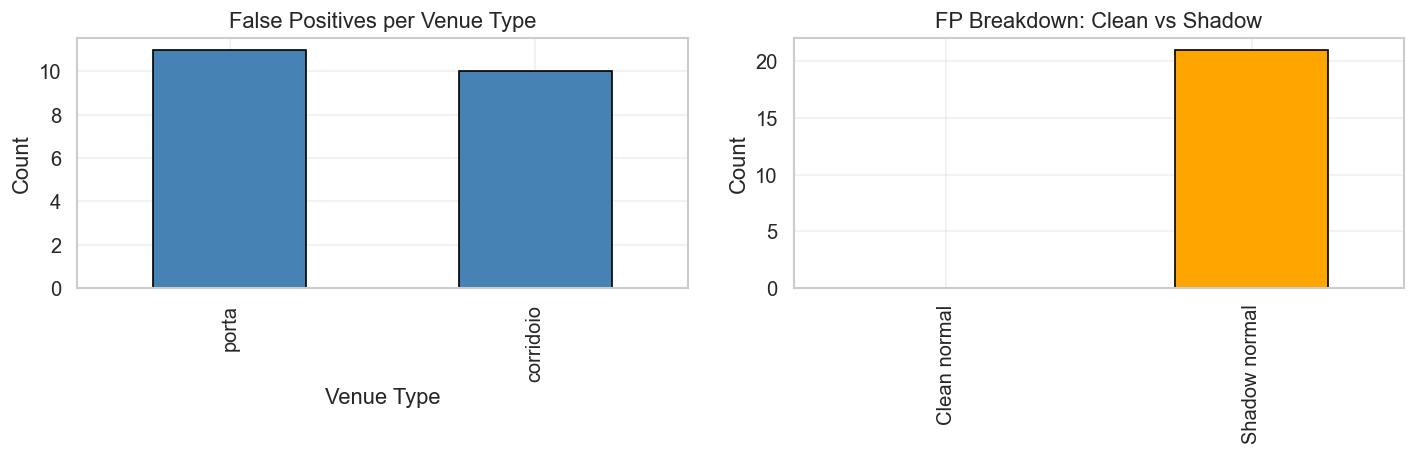

In [23]:
# ── False Positives ─────────────────────────────────────────────────────────
# shadow_normal has is_anomaly=0: flagged shadows count as real FPs.

all_normal_df = pd.concat([normal_df, shadow_df], ignore_index=True)

fp_clean  = normal_df[normal_df['is_anomaly'] == 1]
fp_shadow = shadow_df[shadow_df['is_anomaly'] == 1] if len(shadow_df) > 0 else pd.DataFrame()
fp_all    = all_normal_df[all_normal_df['is_anomaly'] == 1]

print(f'FPR — clean normal only:          {len(fp_clean)}/{len(normal_df)} = {len(fp_clean)/len(normal_df):.2%}')
if len(shadow_df) > 0:
    print(f'FPR — shadow normal only:         {len(fp_shadow)}/{len(shadow_df)} = {len(fp_shadow)/len(shadow_df):.2%}')
    print(f'FPR — combined (clean + shadow):  {len(fp_all)}/{len(all_normal_df)} = {len(fp_all)/len(all_normal_df):.2%}')

print(f'\nTop 10 FPs (all normal images):')
print(fp_all.sort_values('score', ascending=False)[['test_type', 'score', 'threshold', 'venue_type']].head(10).to_string())

if 'venue_type' in df.columns and len(fp_all) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fp_all['venue_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Venue Type')
    axes[0].set_ylabel('Count')
    axes[0].set_title('False Positives per Venue Type')
    axes[0].grid(alpha=0.3)
    if len(shadow_df) > 0:
        pd.Series({'Clean normal': len(fp_clean), 'Shadow normal': len(fp_shadow)}).plot(
            kind='bar', ax=axes[1], color=['green', 'orange'], edgecolor='black')
        axes[1].set_ylabel('Count')
        axes[1].set_title('FP Breakdown: Clean vs Shadow')
        axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No false positives.')

False Negatives: 291 / 990
False Negative Rate: 0.2939

Bottom 10 FNs (hardest to detect):
         score  threshold venue_type
2816  3.659343   4.014856      porta
1880  3.721675   5.185709      porta
998   3.776591   5.043048  corridoio
1562  3.776977   4.276002      porta
215   3.811090   4.215538  corridoio
536   3.815734   4.361166  corridoio
1733  3.852284   5.032379      porta
2885  3.860779   4.644026      porta
2414  3.929242   4.369581      porta
2048  3.932920   4.305547      porta


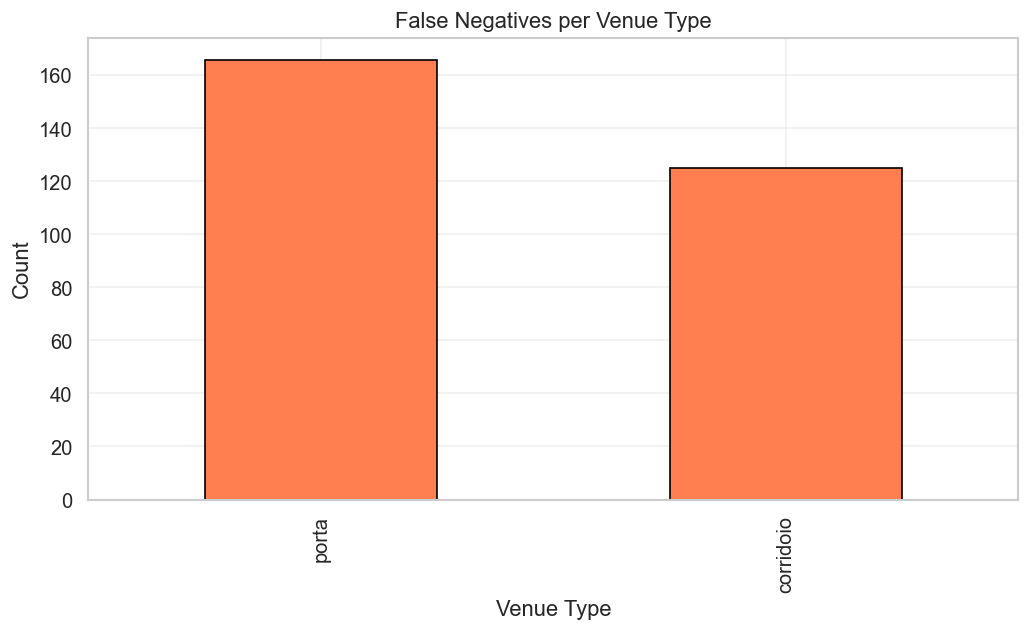

In [24]:
# ── False Negatives ────────────────────────────────────────────────────────────

fn_df = obstructed_df[obstructed_df['is_anomaly'] == 0].sort_values('score', ascending=True)
print(f'False Negatives: {len(fn_df)} / {len(obstructed_df)}')
print(f'False Negative Rate: {len(fn_df)/len(obstructed_df):.4f}')
print('\nBottom 10 FNs (hardest to detect):')
print(fn_df[['score', 'threshold', 'venue_type']].head(10).to_string())

if 'venue_type' in df.columns and len(fn_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    fn_df['venue_type'].value_counts().plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Venue Type')
    ax.set_ylabel('Count')
    ax.set_title('False Negatives per Venue Type')
    ax.grid(alpha=0.3)
    plt.show()
else:
    print('No false negatives.')

---
## 7. Threshold Analysis - FPR / TPR vs k·σ

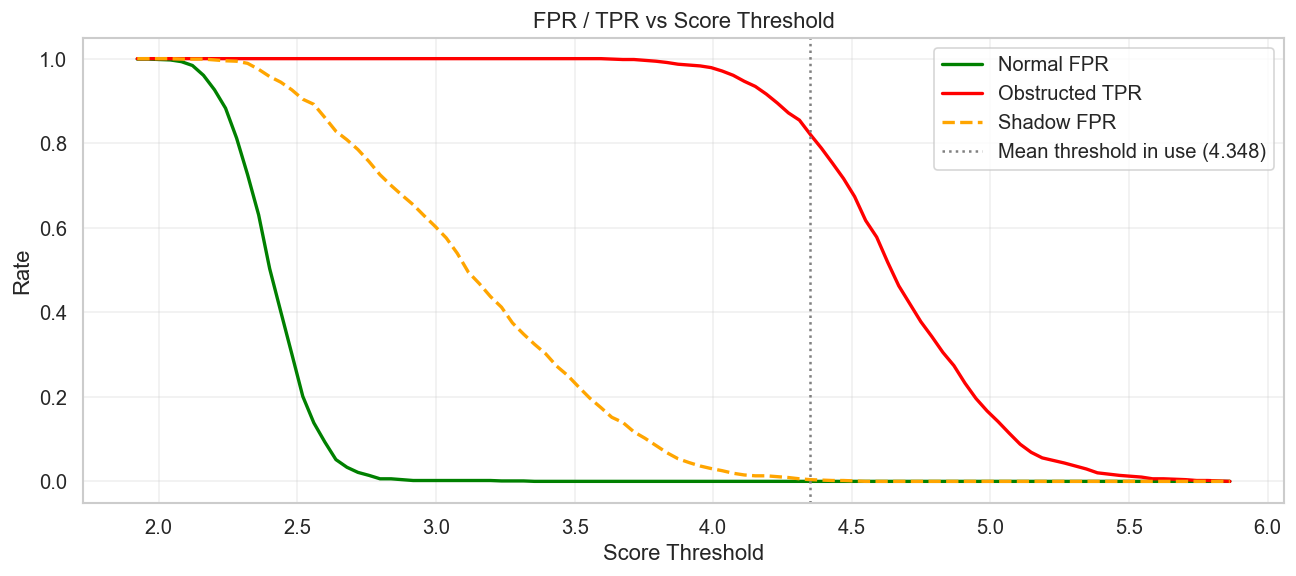

 Threshold |   Normal FPR |   Shadow FPR |    Obstr TPR
     1.922 |       99.9% |       100.0% |      100.0%
     2.241 |       88.3% |        99.5% |      100.0%
     2.559 |       13.8% |        89.2% |      100.0%
     2.878 |        0.4% |        67.7% |      100.0%
     3.196 |        0.2% |        43.7% |      100.0%
     3.515 |        0.0% |        22.3% |      100.0%
     3.833 |        0.0% |         6.8% |       99.1%
     4.152 |        0.0% |         1.3% |       93.4%
     4.470 |        0.0% |         0.2% |       71.6%
     4.789 |        0.0% |         0.0% |       34.2%
     5.107 |        0.0% |         0.0% |        8.8%
     5.426 |        0.0% |         0.0% |        1.7%
     5.744 |        0.0% |         0.0% |        0.2%


In [25]:
# ── Threshold Sensitivity: FPR / TPR vs Score Threshold ──────────────────────
# Sweeps over raw score values. Uses actual per-reference thresholds from the
# CSV only for marking the operating point, not for the sweep itself.

all_group_scores = pd.concat([normal_df['score'], obstructed_df['score'], shadow_df['score']])
thresholds = np.linspace(all_group_scores.min(), all_group_scores.max(), 100)

normal_fprs, shadow_fprs, obstr_tprs = [], [], []
for thr in thresholds:
    normal_fprs.append((normal_df['score'] > thr).mean())
    obstr_tprs.append((obstructed_df['score'] > thr).mean())
    if len(shadow_df) > 0:
        shadow_fprs.append((shadow_df['score'] > thr).mean())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, normal_fprs, label='Normal FPR', linewidth=2, color='green')
ax.plot(thresholds, obstr_tprs, label='Obstructed TPR', linewidth=2, color='red')
if shadow_fprs:
    ax.plot(thresholds, shadow_fprs, label='Shadow FPR', linewidth=2, color='orange', linestyle='--')

mean_thr_used = normal_df['threshold'].mean()
ax.axvline(mean_thr_used, color='gray', linestyle=':', linewidth=1.5,
           label=f'Mean threshold in use ({mean_thr_used:.3f})')

ax.set_xlabel('Score Threshold')
ax.set_ylabel('Rate')
ax.set_title('FPR / TPR vs Score Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'{"Threshold":>10} | {"Normal FPR":>12} | {"Shadow FPR":>12} | {"Obstr TPR":>12}')
step = max(1, len(thresholds) // 12)
for i in range(0, len(thresholds), step):
    thr = thresholds[i]
    sfpr = f'{shadow_fprs[i]:.1%}' if shadow_fprs else 'n/a'
    print(f'{thr:>10.3f} | {normal_fprs[i]:>11.1%} | {sfpr:>12} | {obstr_tprs[i]:>11.1%}')

---
## 8. Heatmap Visualization (overlay from disk)

In [26]:
# ── Heatmap gallery (load from disk if available) ───────────────────────────────

# This section loads anomaly maps (heatmaps) from disk if they exist
# Expected structure: each row should have a 'heatmap_path' column pointing to a .npy or .png

if 'heatmap_path' in df.columns:
    # Sample a few normal and obstructed
    normal_samples = normal_df.dropna(subset=['heatmap_path']).sample(min(3, len(normal_df)), random_state=42)
    obstr_samples = obstructed_df.dropna(subset=['heatmap_path']).sample(min(3, len(obstructed_df)), random_state=42)
    
    for label, samples in [('Normal', normal_samples), ('Obstructed', obstr_samples)]:
        fig = plt.figure(figsize=(12, 4))
        for idx, (_, row) in enumerate(samples.iterrows()):
            ax = fig.add_subplot(1, 3, idx+1)
            try:
                if row['heatmap_path'].endswith('.npy'):
                    hmap = np.load(row['heatmap_path'])
                    im = ax.imshow(hmap, cmap='hot')
                    plt.colorbar(im, ax=ax)
                else:
                    from PIL import Image
                    img = Image.open(row['heatmap_path'])
                    ax.imshow(img)
                ax.set_title(f"Score: {row['score']:.4f}")
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error loading:\n{str(e)[:30]}', 
                       ha='center', va='center', transform=ax.transAxes)
        fig.suptitle(f'{label} Heatmaps', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('No heatmap_path column in data.')

No heatmap_path column in data.


---
## 9. Pair Comparison: Normal vs Obstructed

In [27]:
# ── Pair comparison: reference vs test images ────────────────────────────────

if 'reference_id' in df.columns and 'test_id' in df.columns:
    print('Sample reference-test pairs:')
    sample_pairs = df.drop_duplicates(subset=['reference_id']).sample(min(5, len(df)), random_state=42)
    print(sample_pairs[['reference_id', 'test_id', 'test_type', 'score', 'is_anomaly']].to_string())

    if 'file_path' in df.columns:
        from PIL import Image
        fig = plt.figure(figsize=(14, 4))
        for idx, (_, row) in enumerate(list(sample_pairs.head(3).iterrows())):
            if pd.notna(row.get('file_path')):
                try:
                    img = Image.open(row['file_path'])
                    ax = fig.add_subplot(1, 3, idx + 1)
                    ax.imshow(img)
                    ax.set_title(f"Type: {row['test_type']}\nScore: {row['score']:.3f}")
                    ax.axis('off')
                except Exception as e:
                    print(f'Could not load {row["file_path"]}: {e}')
        plt.tight_layout()
        plt.show()
else:
    print('No reference/test pair information available.')

Sample reference-test pairs:
                                 reference_id                                  test_id test_type     score  is_anomaly
639   non_ostruite/corridoi/corridoio_238.jpg  non_ostruite/corridoi/corridoio_238.jpg    normal  2.430736           0
993   non_ostruite/corridoi/corridoio_371.jpg  non_ostruite/corridoi/corridoio_371.jpg    normal  2.231799           0
1503         non_ostruite/porte/porta_009.jpg         non_ostruite/porte/porta_009.jpg    normal  2.168454           0
927   non_ostruite/corridoi/corridoio_344.jpg  non_ostruite/corridoi/corridoio_344.jpg    normal  2.350936           0
264   non_ostruite/corridoi/corridoio_097.jpg  non_ostruite/corridoi/corridoio_097.jpg    normal  2.483097           0
Could not load non_ostruite/corridoi/corridoio_238.jpg: [Errno 2] No such file or directory: 'non_ostruite/corridoi/corridoio_238.jpg'
Could not load non_ostruite/corridoi/corridoio_371.jpg: [Errno 2] No such file or directory: 'non_ostruite/corridoi/corrid

<Figure size 1680x480 with 0 Axes>

---
## 10. Final Numerical Summary

In [28]:
# ── Final Summary ────────────────────────────────────────────────────────────────

print('=' * 62)
print('         PatchCore Anomaly Detection — Summary')
print('=' * 62)
print()

all_normal_df = pd.concat([normal_df, shadow_df], ignore_index=True)

print('Dataset size:')
print(f'  Clean normal images: {len(normal_df):6d}')
if len(shadow_df) > 0:
    print(f'  Shadow normal images:{len(shadow_df):6d}')
print(f'  Obstructed images:   {len(obstructed_df):6d}')
print()

print('Discrimination (Normal vs Obstructed):')
print(f'  AUROC:               {auroc:.4f}')
print(f'  AP:                  {ap:.4f}')
print()

tp         = obstructed_df['is_anomaly'].sum()
fn_n       = (obstructed_df['is_anomaly'] == 0).sum()
fp_clean_n = normal_df['is_anomaly'].sum()
fp_shadow_n = shadow_df['is_anomaly'].sum() if len(shadow_df) > 0 else 0
fp_all_n   = all_normal_df['is_anomaly'].sum()

recall    = tp / len(obstructed_df)
precision = tp / max(tp + fp_all_n, 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

print('Classification (per-reference adaptive thresholds):')
print(f'  Recall    (TPR):     {recall:.4f}  ({recall:.2%})')
print(f'  Precision:           {precision:.4f}  ({precision:.2%})')
print(f'  F1 score:            {f1:.4f}')
print()
print(f'  FPR — clean normal:  {fp_clean_n:4d}/{len(normal_df)} = {fp_clean_n/len(normal_df):.2%}')
if len(shadow_df) > 0:
    print(f'  FPR — shadow normal: {fp_shadow_n:4d}/{len(shadow_df)} = {fp_shadow_n/len(shadow_df):.2%}')
    print(f'  FPR — combined:      {fp_all_n:4d}/{len(all_normal_df)} = {fp_all_n/len(all_normal_df):.2%}')
print(f'  FNR — obstructed:    {fn_n:4d}/{len(obstructed_df)} = {fn_n/len(obstructed_df):.2%}')
print()

if 'venue_type' in df.columns:
    print('Samples by venue:')
    for venue in sorted(df['venue_type'].unique()):
        if venue != 'n/a':
            print(f'  {venue:15s}: {len(df[df["venue_type"]==venue]):6d}')

print()
print('Analysis complete.')

         PatchCore Anomaly Detection — Summary

Dataset size:
  Clean normal images:    990
  Shadow normal images:   990
  Obstructed images:      990

Discrimination (Normal vs Obstructed):
  AUROC:               1.0000
  AP:                  1.0000

Classification (per-reference adaptive thresholds):
  Recall    (TPR):     0.7061  (70.61%)
  Precision:           0.9708  (97.08%)
  F1 score:            0.8175

  FPR — clean normal:     0/990 = 0.00%
  FPR — shadow normal:   21/990 = 2.12%
  FPR — combined:        21/1980 = 1.06%
  FNR — obstructed:     291/990 = 29.39%

Samples by venue:
  corridoio      :   1485
  porta          :   1485

Analysis complete.
